# Marginal Distribution Examples

This notebook demonstrates marginal distributions with practical examples.

## Example 1: Discrete Joint Distribution - Height and Weight

Let's create a joint probability distribution table for Height and Weight.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Create joint probability distribution P(Height, Weight)
joint_prob = pd.DataFrame({
    'Light': [0.10, 0.15, 0.05],
    'Medium': [0.15, 0.25, 0.10],
    'Heavy': [0.05, 0.10, 0.05]
}, index=['Tall', 'Medium', 'Short'])

print("Joint Probability Distribution P(Height, Weight):")
print(joint_prob)
print(f"\nSum of all probabilities: {joint_prob.values.sum():.2f}")

Joint Probability Distribution P(Height, Weight):
        Light  Medium  Heavy
Tall     0.10    0.15   0.05
Medium   0.15    0.25   0.10
Short    0.05    0.10   0.05

Sum of all probabilities: 1.00


### Computing Marginal Distributions

**Marginal distribution of Height**: Sum across all weight categories (sum rows)

**Marginal distribution of Weight**: Sum across all height categories (sum columns)

In [3]:
# Marginal distribution of Height: P(Height) = Σ P(Height, Weight) over all Weight
marginal_height = joint_prob.sum(axis=1)

# Marginal distribution of Weight: P(Weight) = Σ P(Height, Weight) over all Height
marginal_weight = joint_prob.sum(axis=0)

print("Marginal Distribution of Height:")
print(marginal_height)
print(f"\nSum: {marginal_height.sum():.2f}")

print("\n" + "="*50)
print("\nMarginal Distribution of Weight:")
print(marginal_weight)
print(f"\nSum: {marginal_weight.sum():.2f}")

Marginal Distribution of Height:
Tall      0.3
Medium    0.5
Short     0.2
dtype: float64

Sum: 1.00


Marginal Distribution of Weight:
Light     0.3
Medium    0.5
Heavy     0.2
dtype: float64

Sum: 1.00


In [4]:
# Create a complete table with marginals in the margins
complete_table = joint_prob.copy()
complete_table['Marginal (Height)'] = marginal_height
complete_table.loc['Marginal (Weight)'] = list(marginal_weight) + [1.0]

print("Complete Table with Marginal Distributions:")
print(complete_table)

Complete Table with Marginal Distributions:
                   Light  Medium  Heavy  Marginal (Height)
Tall                0.10    0.15   0.05                0.3
Medium              0.15    0.25   0.10                0.5
Short               0.05    0.10   0.05                0.2
Marginal (Weight)   0.30    0.50   0.20                1.0


### Visualization

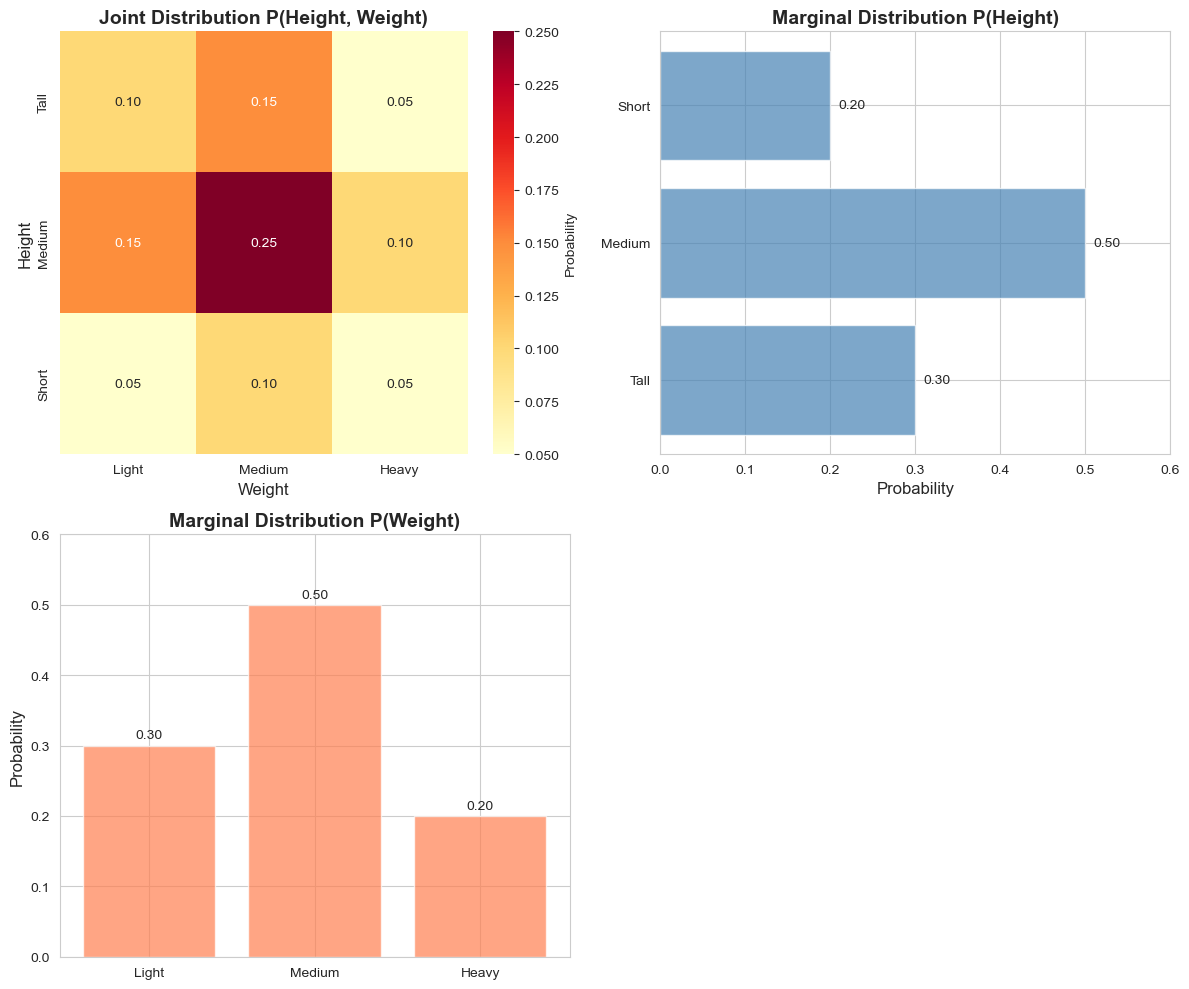

In [5]:
# Visualize the joint and marginal distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Joint distribution heatmap
sns.heatmap(joint_prob, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0, 0], cbar_kws={'label': 'Probability'})
axes[0, 0].set_title('Joint Distribution P(Height, Weight)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Height', fontsize=12)
axes[0, 0].set_xlabel('Weight', fontsize=12)

# Marginal distribution of Height
axes[0, 1].barh(marginal_height.index, marginal_height.values, color='steelblue', alpha=0.7)
axes[0, 1].set_xlabel('Probability', fontsize=12)
axes[0, 1].set_title('Marginal Distribution P(Height)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim(0, 0.6)
for i, v in enumerate(marginal_height.values):
    axes[0, 1].text(v + 0.01, i, f'{v:.2f}', va='center')

# Marginal distribution of Weight
axes[1, 0].bar(marginal_weight.index, marginal_weight.values, color='coral', alpha=0.7)
axes[1, 0].set_ylabel('Probability', fontsize=12)
axes[1, 0].set_title('Marginal Distribution P(Weight)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylim(0, 0.6)
for i, v in enumerate(marginal_weight.values):
    axes[1, 0].text(i, v + 0.01, f'{v:.2f}', ha='center')

# Hide the fourth subplot
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Example 2: Continuous Joint Distribution

Let's simulate a bivariate normal distribution and compute marginal distributions.

In [6]:
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

# Generate bivariate normal data
mean = [0, 0]
cov = [[1, 0.6], [0.6, 1]]  # Covariance matrix with correlation 0.6
n_samples = 5000

data = np.random.multivariate_normal(mean, cov, n_samples)
x = data[:, 0]
y = data[:, 1]

print(f"Generated {n_samples} samples from bivariate normal distribution")
print(f"Mean X: {x.mean():.3f}, Mean Y: {y.mean():.3f}")
print(f"Std X: {x.std():.3f}, Std Y: {y.std():.3f}")
print(f"Correlation: {np.corrcoef(x, y)[0, 1]:.3f}")

Generated 5000 samples from bivariate normal distribution
Mean X: 0.004, Mean Y: 0.005
Std X: 1.001, Std Y: 1.006
Correlation: 0.600


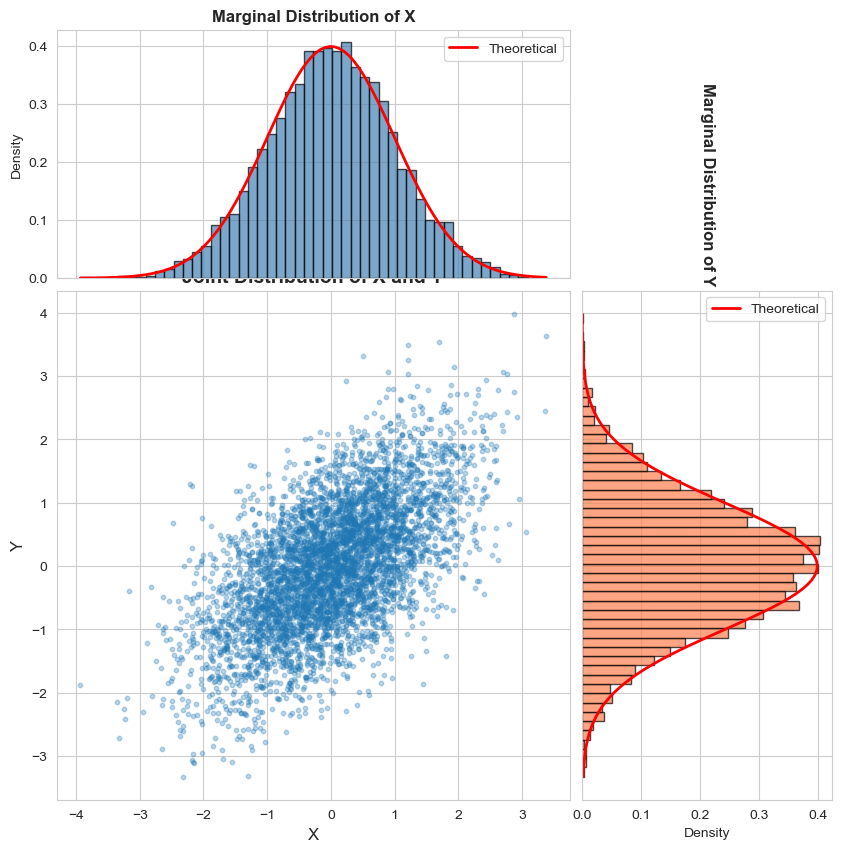

In [ ]:
# Visualize joint distribution and marginals
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(3, 3, hspace=0.05, wspace=0.05)

# Main plot: Joint distribution
ax_main = fig.add_subplot(gs[1:, :-1])
ax_main.scatter(x, y, alpha=0.3, s=10)
ax_main.set_xlabel('X', fontsize=12)
ax_main.set_ylabel('Y', fontsize=12)
ax_main.set_title('Joint Distribution of X and Y', fontsize=14, fontweight='bold')

# Top plot: Marginal distribution of X
ax_top = fig.add_subplot(gs[0, :-1], sharex=ax_main)
ax_top.hist(x, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
# Overlay theoretical normal distribution
x_range = np.linspace(x.min(), x.max(), 100)
ax_top.plot(x_range, stats.norm.pdf(x_range, 0, 1), 'r-', linewidth=2, label='Theoretical')
ax_top.set_ylabel('Density', fontsize=10)
ax_top.set_title('Marginal Distribution of X', fontsize=12, fontweight='bold')
ax_top.legend()
ax_top.tick_params(labelbottom=False)

# Right plot: Marginal distribution of Y
ax_right = fig.add_subplot(gs[1:, -1], sharey=ax_main)
ax_right.hist(y, bins=50, density=True, alpha=0.7, color='coral', edgecolor='black', orientation='horizontal')
# Overlay theoretical normal distribution
y_range = np.linspace(y.min(), y.max(), 100)
ax_right.plot(stats.norm.pdf(y_range, 0, 1), y_range, 'r-', linewidth=2, label='Theoretical')
ax_right.set_xlabel('Density', fontsize=10)
ax_right.set_title('Marginal Distribution of Y', fontsize=12, fontweight='bold', rotation=270 ) #labelpad=20
ax_right.legend()
ax_right.tick_params(labelleft=False)

plt.show()

## Example 3: Real-World Application - Student Grades

Let's analyze the joint distribution of Math and English grades.

In [9]:
# Create sample data
np.random.seed(123)
n_students = 1000

# Simulate grades with some correlation
math_grades = np.random.normal(75, 12, n_students)
english_grades = 0.5 * math_grades + np.random.normal(40, 8, n_students)

# Clip to valid grade range
math_grades = np.clip(math_grades, 0, 100)
english_grades = np.clip(english_grades, 0, 100)

# Create grade categories
def categorize_grade(grade):
    if grade >= 90:
        return 'A'
    elif grade >= 80:
        return 'B'
    elif grade >= 70:
        return 'C'
    elif grade >= 60:
        return 'D'
    else:
        return 'F'

math_categories = [categorize_grade(g) for g in math_grades]
english_categories = [categorize_grade(g) for g in english_grades]

# Create DataFrame
grades_df = pd.DataFrame({
    'Math': math_categories,
    'English': english_categories
})

print(f"Total students: {n_students}")
print(f"\nFirst 10 students:")
print(grades_df.head(10))

Total students: 1000

First 10 students:
  Math English
0    D       D
1    B       B
2    C       B
3    F       D
4    D       C
5    A       C
6    F       D
7    D       D
8    A       C
9    D       D


In [10]:
# Create contingency table (joint frequency)
joint_freq = pd.crosstab(grades_df['Math'], grades_df['English'], margins=False)

# Convert to joint probability
joint_prob_grades = joint_freq / n_students

print("Joint Probability Distribution P(Math, English):")
print(joint_prob_grades.round(3))

Joint Probability Distribution P(Math, English):
English      A      B      C      D      F
Math                                      
A        0.039  0.040  0.021  0.002  0.000
B        0.032  0.090  0.071  0.018  0.000
C        0.024  0.115  0.157  0.047  0.003
D        0.001  0.037  0.103  0.070  0.011
F        0.000  0.004  0.041  0.057  0.017


In [11]:
# Compute marginal distributions
marginal_math = joint_prob_grades.sum(axis=1)
marginal_english = joint_prob_grades.sum(axis=0)

print("Marginal Distribution of Math Grades:")
print(marginal_math.round(3))
print(f"\nSum: {marginal_math.sum():.3f}")

print("\n" + "="*50)
print("\nMarginal Distribution of English Grades:")
print(marginal_english.round(3))
print(f"\nSum: {marginal_english.sum():.3f}")

Marginal Distribution of Math Grades:
Math
A    0.102
B    0.211
C    0.346
D    0.222
F    0.119
dtype: float64

Sum: 1.000


Marginal Distribution of English Grades:
English
A    0.096
B    0.286
C    0.393
D    0.194
F    0.031
dtype: float64

Sum: 1.000


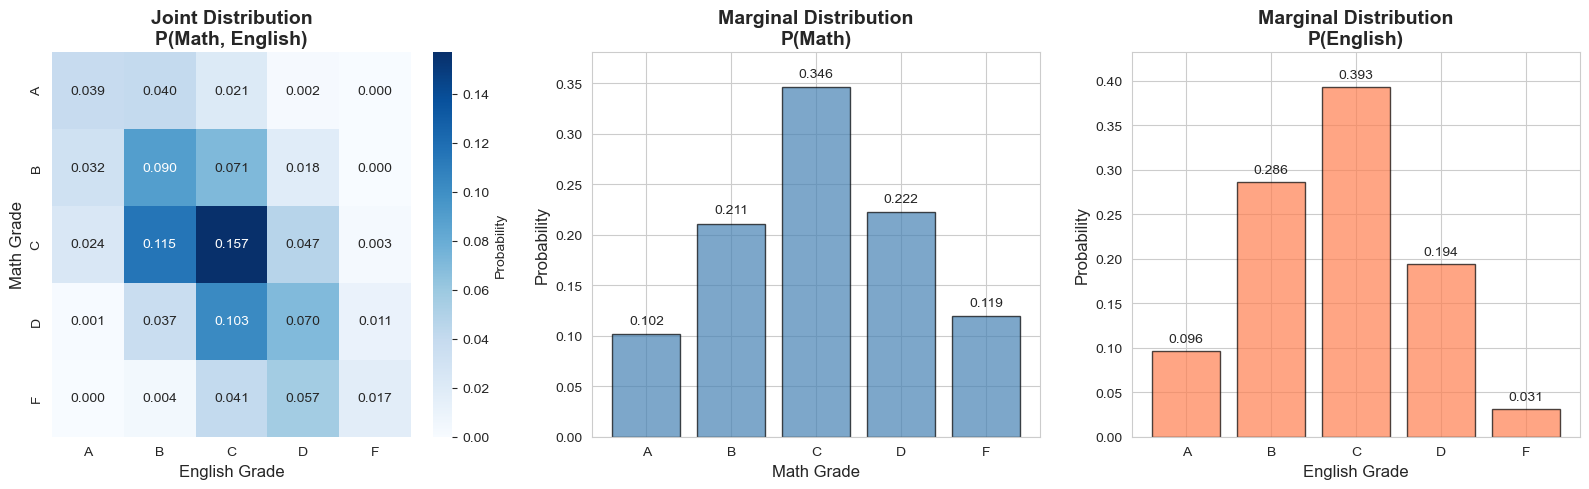

In [12]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Joint distribution
sns.heatmap(joint_prob_grades, annot=True, fmt='.3f', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Probability'})
axes[0].set_title('Joint Distribution\nP(Math, English)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('English Grade', fontsize=12)
axes[0].set_ylabel('Math Grade', fontsize=12)

# Marginal distribution of Math
grade_order = ['A', 'B', 'C', 'D', 'F']
marginal_math_sorted = marginal_math.reindex(grade_order, fill_value=0)
axes[1].bar(marginal_math_sorted.index, marginal_math_sorted.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].set_title('Marginal Distribution\nP(Math)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Math Grade', fontsize=12)
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_ylim(0, max(marginal_math_sorted.values) * 1.1)
for i, v in enumerate(marginal_math_sorted.values):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

# Marginal distribution of English
marginal_english_sorted = marginal_english.reindex(grade_order, fill_value=0)
axes[2].bar(marginal_english_sorted.index, marginal_english_sorted.values, color='coral', alpha=0.7, edgecolor='black')
axes[2].set_title('Marginal Distribution\nP(English)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('English Grade', fontsize=12)
axes[2].set_ylabel('Probability', fontsize=12)
axes[2].set_ylim(0, max(marginal_english_sorted.values) * 1.1)
for i, v in enumerate(marginal_english_sorted.values):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Key Takeaways

1. **Marginal distribution** gives the probability distribution of a subset of variables by summing/integrating over the other variables

2. **For discrete variables**: P(X) = Σ P(X, Y) for all values of Y

3. **For continuous variables**: f_X(x) = ∫ f(x, y) dy

4. **The name "marginal"** comes from writing these distributions in the margins of probability tables

5. **Marginal distributions** allow us to focus on individual variables while ignoring others in a multivariate setting